<a href="https://colab.research.google.com/github/Vishalkumar800/Titanic-Dataset-Cleaning-and-EDA-/blob/main/complete_titanic_model_ai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_csv("train.csv")
test_data = pd.read_csv("test.csv")
data.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
data_df = data.copy()
data_test = test_data.copy()

In [ ]:
data_test.head(2)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S


In [ ]:
# axis  = 0 rows
# axis = 1 column
data_df.drop(["Cabin"] , axis = 1,  inplace = True )
data_test.drop(["Cabin"] , inplace= True , axis= 1)


```
In test.csv one column is missing that is survived column because that is test column.

```

```
Survived : 0 (Not Survived ) and 1 means alive
PClass : means which class passenger is in like 1(first class ), 2 (secondclass) , 3 (thirdclass)

SibSp : Siblings + Spouses
```
Siblings means brother or sister where as spouses husband/wife.

```
Parch : Parent + Childern
Fare : Price of ticket

```

 `Embarked`  You can call station name
  | Code | Port        |
 | ----  | ----------- |
| `C`   | Cherbourg   |
| `Q`   | Queenstown  |
| `S`   | Southampton |

`Numerical` : Age , Fare

`Categorical`  : Categorical , PClass , Survived , Sex , SibSp , Parch , Embarked

`Mixed` : Name , Ticket



In [ ]:
# function is used to perform an action or operation . In hindi function se kaam aap kuch karwate ho
# attributes : An attribute is a property or piece of information associated with an object. It tells us what the object has or what it is like.
### where as attributes se information lete ho.

data_df.info() , data_df.shape # shape is attributes means



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


(None, (891, 11))

In [ ]:
data_df["Age"].describe()

,Age
count,714.000000
mean,29.699118
std,14.526497
min,0.420000
25%,20.125000
50%,28.000000
75%,38.000000
max,80.000000


## Problems in these dataset

```
Name : I need to split the original `Name` column into two separate columns: `NameOnly` , title and `Surname`.

Age : Age has so missing values so I need to handle it .

Fare : Fair column contains whole family ticket price example if a family hai 4 members then fair contain whole ticket price of family

SibSp + Parch combine these two columns and create a new column that is family size.

so i need to find single member ticket price.

Embarked = Two missing values.

```

In [ ]:
data_df.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C


In [ ]:
data_df["SurName"] = data_df["Name"].str.split(",").str[0]
data_test["SurName"] = data_df["Name"].str.split(",").str[0]

In [ ]:
data_df["NameOnly"] = data_df["Name"].str.split(",").str[1]
data_test["NameOnly"] = data_df["Name"].str.split(",").str[1]

In [ ]:
data_df["title"] = data_df["NameOnly"].str.split(".").str[0]
data_test["title"] = data_df["NameOnly"].str.split(".").str[0]

In [ ]:
data_df["Name_Single"] = data_df["NameOnly"].str.split(".").str[1]
data_test["Name_Single"] = data_df["NameOnly"].str.split(".").str[1]

In [ ]:
data_df.drop(["NameOnly"] , axis=1 , inplace=True)
data_test.drop(["NameOnly"] , axis=1 , inplace=True)

In [ ]:
data_df["family"] = data_df["SibSp"] + data_df["Parch"] +1
data_test["family"] = data_df["SibSp"] + data_df["Parch"] +1

In [ ]:
data_df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,SurName,title,Name_Single,family
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,Braund,Mr,Owen Harris,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,Cumings,Mrs,John Bradley (Florence Briggs Thayer),2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,Heikkinen,Miss,Laina,1


In [ ]:
data_df.drop(["SibSp" , "Parch"], axis = 1, inplace = True)
data_test.drop(["SibSp" , "Parch"], axis = 1, inplace = True)

In [ ]:
data_df["family"].value_counts()

,count
family,
1,537
2,161
3,102
4,29
6,22
5,15
7,12
11,7
8,6


In [ ]:
def family_size(n):
  if n ==1 :
    return "alone"
  elif n > 1 and n < 5 :
    return "small"
  else:
    return "large"

In [ ]:
data_df["family_type"] = data_df["family"].apply(family_size)
data_test["family_type"] = data_df["family"].apply(family_size)

In [ ]:
data_df.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Embarked,SurName,title,Name_Single,family,family_type
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,A/5 21171,7.2500,S,Braund,Mr,Owen Harris,2,small
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,PC 17599,71.2833,C,Cumings,Mrs,John Bradley (Florence Briggs Thayer),2,small


In [ ]:
data_df["family"].value_counts()

,count
family,
1,537
2,161
3,102
4,29
6,22
5,15
7,12
11,7
8,6


In [ ]:
data_df[data_df["family"] == 8 ]

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Embarked,SurName,title,Name_Single,family,family_type
59,60,0,3,"Goodwin, Master. William Frederick",male,11.0,CA 2144,46.9,S,Goodwin,Master,William Frederick,8,large
71,72,0,3,"Goodwin, Miss. Lillian Amy",female,16.0,CA 2144,46.9,S,Goodwin,Miss,Lillian Amy,8,large
386,387,0,3,"Goodwin, Master. Sidney Leonard",male,1.0,CA 2144,46.9,S,Goodwin,Master,Sidney Leonard,8,large
480,481,0,3,"Goodwin, Master. Harold Victor",male,9.0,CA 2144,46.9,S,Goodwin,Master,Harold Victor,8,large
678,679,0,3,"Goodwin, Mrs. Frederick (Augusta Tyler)",female,43.0,CA 2144,46.9,S,Goodwin,Mrs,Frederick (Augusta Tyler),8,large
683,684,0,3,"Goodwin, Mr. Charles Edward",male,14.0,CA 2144,46.9,S,Goodwin,Mr,Charles Edward,8,large


In [ ]:
data_df["individualFare"] = data_df["Fare"] / data_df["family"]
data_test["individualFare"] = data_df["Fare"] / data_df["family"]

In [ ]:
data_df.drop("Fare", axis = 1 , inplace=True)
data_test.drop("Fare", axis = 1 , inplace=True)

In [ ]:
data_df.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Embarked,SurName,title,Name_Single,family,family_type,individualFare
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,A/5 21171,S,Braund,Mr,Owen Harris,2,small,3.62500
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,PC 17599,C,Cumings,Mrs,John Bradley (Florence Briggs Thayer),2,small,35.64165


In [ ]:
data_df["title"].value_counts()

,count
title,
Mr,517
Miss,182
Mrs,125
Master,40
Dr,7
Rev,6
Col,2
Mlle,2
Major,2


In [ ]:
print(data_df["title"].unique())

[' Mr' ' Mrs' ' Miss' ' Master' ' Don' ' Rev' ' Dr' ' Mme' ' Ms' ' Major'
 ' Lady' ' Sir' ' Mlle' ' Col' ' Capt' ' the Countess' ' Jonkheer']


In [ ]:
mr = ["Mr", "Col", "Major", "Don", "Sir", "Capt", "Dr", "Rev", "Jonkheer" , "Master"]

miss = ["Miss", "Mrs", "Ms", "Mlle", "Mme", "Lady", "the Countess"]

def titleFunc(title):
  title = title.strip()
  if title in mr:
    return "Mr"
  elif title in miss:
    return "Miss"
  else:
    return "Other"

In [ ]:
data_df["title"] = data_df["title"].apply(titleFunc)
data_test["title"] = data_df["title"].apply(titleFunc)

In [ ]:
data_df["title"].value_counts()

,count
title,
Mr,578
Miss,313


In [ ]:
data_df.drop(["Name"] , axis = 1 , inplace = True)
data_test.drop(["Name"] , axis = 1 , inplace = True)

<Axes: ylabel='Density'>

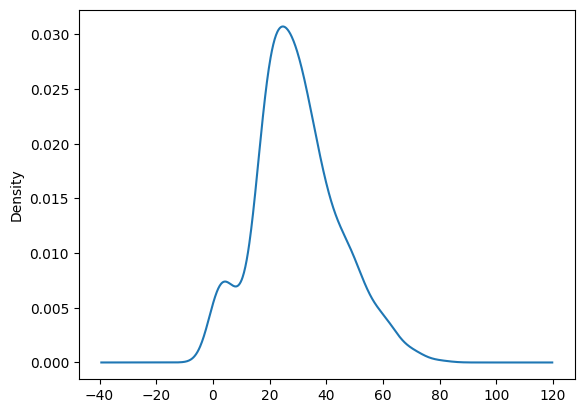

In [ ]:
data_df["Age"].plot(kind="kde")

In [ ]:
data_df["Age"] = data_df["Age"].fillna(data_df["Age"].median())
data_test["Age"] = data_test["Age"].fillna(data_df["Age"].median())

In [ ]:
data_df["Embarked"] = data_df["Embarked"].fillna(value="S")
data_test["Embarked"] = data_test["Embarked"].fillna(value="S")


In [ ]:
data_df.head()

,PassengerId,Survived,Pclass,Sex,Age,Ticket,Embarked,SurName,title,Name_Single,family,family_type,individualFare
0,1,0,3,male,22.0,A/5 21171,S,Braund,Mr,Owen Harris,2,small,3.62500
1,2,1,1,female,38.0,PC 17599,C,Cumings,Miss,John Bradley (Florence Briggs Thayer),2,small,35.64165
2,3,1,3,female,26.0,STON/O2. 3101282,S,Heikkinen,Miss,Laina,1,alone,7.92500
3,4,1,1,female,35.0,113803,S,Futrelle,Miss,Jacques Heath (Lily May Peel),2,small,26.55000
4,5,0,3,male,35.0,373450,S,Allen,Mr,William Henry,1,alone,8.05000


<Axes: xlabel='Age', ylabel='Density'>

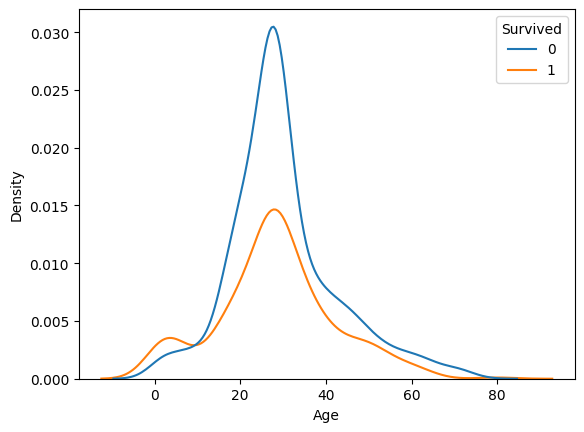

In [ ]:
sns.kdeplot(data = data_df , x = "Age" , hue = "Survived")

```
esme yeah ensite nikli agr aap ki age 10 se km hai toh Survived karne ka chance hai

but dekho yellow wala

```

In [ ]:
data_df

,PassengerId,Survived,Pclass,Sex,Age,Ticket,Embarked,SurName,title,Name_Single,family,family_type,individualFare
0,1,0,3,male,22.0,A/5 21171,S,Braund,Mr,Owen Harris,2,small,3.62500
1,2,1,1,female,38.0,PC 17599,C,Cumings,Miss,John Bradley (Florence Briggs Thayer),2,small,35.64165
2,3,1,3,female,26.0,STON/O2. 3101282,S,Heikkinen,Miss,Laina,1,alone,7.92500
3,4,1,1,female,35.0,113803,S,Futrelle,Miss,Jacques Heath (Lily May Peel),2,small,26.55000
4,5,0,3,male,35.0,373450,S,Allen,Mr,William Henry,1,alone,8.05000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,male,27.0,211536,S,Montvila,Mr,Juozas,1,alone,13.00000
887,888,1,1,female,19.0,112053,S,Graham,Miss,Margaret Edith,1,alone,30.00000
888,889,0,3,female,28.0,W./C. 6607,S,Johnston,Miss,"Catherine Helen ""Carrie""",4,small,5.86250
889,890,1,1,male,26.0,111369,C,Behr,Mr,Karl Howell,1,alone,30.00000


In [ ]:
# Y(target) = Survived

## Nominal Column.

`Sex , Embarked , title `

## Ordinal Column

`family type `


` `

# Sex column me 0 and 1 daal skhta hu na check ya ordinal bhi same krega


`Research `

```
NameSingle
Ticket
Surname

```

In [ ]:
test_passenger_Id = data_test["PassengerId"]

data_df.drop("PassengerId",axis=1,inplace=True)
data_test.drop("PassengerId",axis = 1, inplace=True)

In [ ]:
drop_cols = ["SurName","Name_Single","family","Ticket"]
x = data_df.drop(["Survived"] + drop_cols, axis=1)
y = data_df.iloc[:,0]


In [ ]:
x_test = data_test.drop(drop_cols , axis=1)

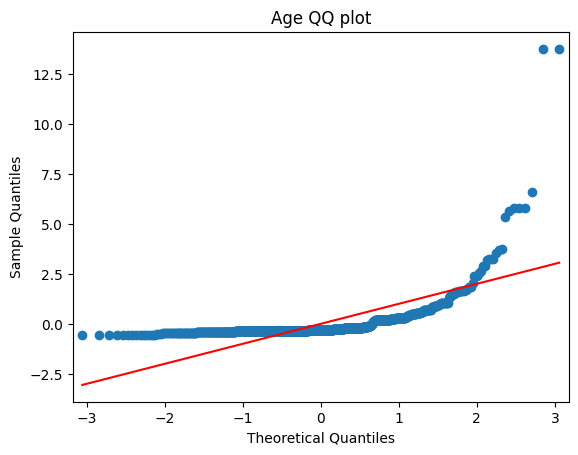

In [ ]:
import statsmodels.api as sm

sm.qqplot(x["individualFare"] , line ="s" , fit = True)
plt.title("Age QQ plot")
plt.show()

In [ ]:
from sklearn.pipeline import FunctionTransformer
from sklearn.compose import ColumnTransformer

ct = ColumnTransformer(
    transformers = [
        ("log",FunctionTransformer(np.log1p) , ["individualFare"])
    ],
    remainder = "passthrough"
)

ct.fit(x[["individualFare"]])
x[["individualFare"]] = ct.transform(x[["individualFare"]])
x_test[["individualFare"]] = ct.transform(x_test[["individualFare"]])

In [ ]:
x

,Pclass,Sex,Age,Embarked,title,family_type,individualFare
0,3,male,22.0,S,Mr,small,1.531476
1,1,female,38.0,C,Miss,small,3.601186
2,3,female,26.0,S,Miss,alone,2.188856
3,1,female,35.0,S,Miss,small,3.316003
4,3,male,35.0,S,Mr,alone,2.202765
...,...,...,...,...,...,...,...
886,2,male,27.0,S,Mr,alone,2.639057
887,1,female,19.0,S,Miss,alone,3.433987
888,3,female,28.0,S,Miss,small,1.926072
889,1,male,26.0,C,Mr,alone,3.433987


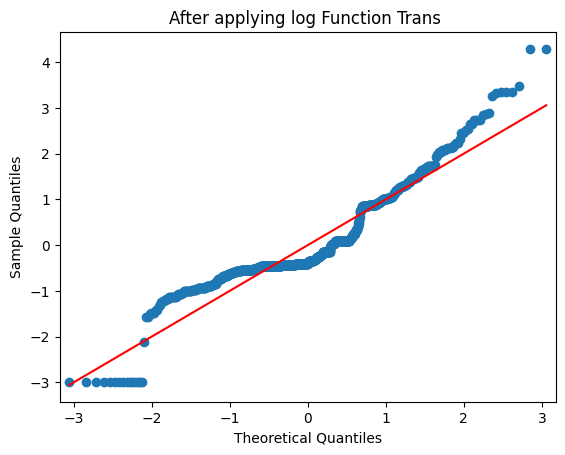

In [ ]:
sm.qqplot(x["individualFare"] ,line  = "s" , fit = True)
plt.title("After applying log Function Trans ")
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

sc.fit(x[["Age","individualFare"]])

x[["Age","individualFare"]] =sc.transform(x[["Age","individualFare"]])
x_test[["Age","individualFare"]] = sc.transform(x_test[["Age","individualFare"]])

In [ ]:
# from sklearn.preprocessing import MinMaxScaler

# mm = MinMaxScaler()

# mm.fit(x[["Age","individualFare"]])

# x[["Age","individualFare"]] =mm.transform(x[["Age","individualFare"]])
# x_test[["Age","individualFare"]] = mm.transform(x_test[["Age","individualFare"]])

In [ ]:
x

,Pclass,Sex,Age,Embarked,title,family_type,individualFare
0,3,male,-0.565736,S,Mr,small,-1.205713
1,1,female,0.663861,C,Miss,small,1.208790
2,3,female,-0.258337,S,Miss,alone,-0.438820
3,1,female,0.433312,S,Miss,small,0.876098
4,3,male,0.433312,S,Mr,alone,-0.422594
...,...,...,...,...,...,...,...
886,2,male,-0.181487,S,Mr,alone,0.086381
887,1,female,-0.796286,S,Miss,alone,1.013738
888,3,female,-0.104637,S,Miss,small,-0.745381
889,1,male,-0.258337,C,Mr,alone,1.013738


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder , OrdinalEncoder

categories = [["alone","small" , "large"]]

ct = ColumnTransformer(
    transformers= [
        ("nominal", OneHotEncoder(sparse_output=False , drop="first"), ["Sex" ,"Embarked","title"]),
        ("ord" , OrdinalEncoder(categories=categories),["family_type"])
    ],
  remainder="passthrough"
)

In [ ]:
ct.fit(x)
x = ct.transform(x)
data_test = ct.transform(x_test)

In [ ]:
data_frame = pd.DataFrame(x , columns = ct.get_feature_names_out())
data_frame

,nominal__Sex_male,nominal__Embarked_Q,nominal__Embarked_S,nominal__title_Mr,ord__family_type,remainder__Pclass,remainder__Age,remainder__individualFare
0,1.0,0.0,1.0,1.0,1.0,3.0,-0.565736,-1.205713
1,0.0,0.0,0.0,0.0,1.0,1.0,0.663861,1.208790
2,0.0,0.0,1.0,0.0,0.0,3.0,-0.258337,-0.438820
3,0.0,0.0,1.0,0.0,1.0,1.0,0.433312,0.876098
4,1.0,0.0,1.0,1.0,0.0,3.0,0.433312,-0.422594
...,...,...,...,...,...,...,...,...
886,1.0,0.0,1.0,1.0,0.0,2.0,-0.181487,0.086381
887,0.0,0.0,1.0,0.0,0.0,1.0,-0.796286,1.013738
888,0.0,0.0,1.0,0.0,1.0,3.0,-0.104637,-0.745381
889,1.0,0.0,0.0,1.0,0.0,1.0,-0.258337,1.013738


## Now I have ready train and test data to pass ml model

`x`
`x_test`

In [ ]:
# from sklearn.linear_model import LogisticRegression

# lr = LogisticRegression()

# lr.fit(x,y)

# y_pred_lr = lr.predict(data_test)

In [ ]:
# from sklearn.tree import DecisionTreeClassifier

# dt = DecisionTreeClassifier(
#     random_state = 40
# )

# dt.fit(x,y)

# y_pred_dt = dt.predict(data_test)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(x, y)

y_pred_rf = rf.predict(data_test)

In [ ]:
submission = pd.DataFrame({
    "PassengerId" : test_passenger_Id,
    "Survived" : y_pred_rf
})


In [ ]:
submission.to_csv("randomforesttitanic5.csv",index=False)